# CNN (ResNet-50) vs Vision Transformer (ViT-B/32) on EuroSAT
This notebook compares a CNN (ResNet-50) and a Vision Transformer (ViT-B/32) for land-cover classification using the EuroSAT dataset. Both models use ImageNet pretrained weights and are fine-tuned on the EuroSAT dataset.

The experiments compare the models based on their classification performance, data efficiency, robustness to image corruption, sensitivity to hyperparameters, and the effect of transfer learning and data augmentation.

## 0. Setup

In [ ]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
SEEDS = [42, 123]
BATCH_SIZE = 64
EPOCHS = 8
DE_EPOCHS = 5
HP_EPOCHS = 4
LR = 5e-5

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEEDS[0])

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('Using device:', device)

Using device: cpu


## 1. Load and explore the dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.EuroSAT(root='./data', download=True, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)

print(f'Total samples: {len(full_dataset)}')
print(f'Classes: {class_names}')

Total samples: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


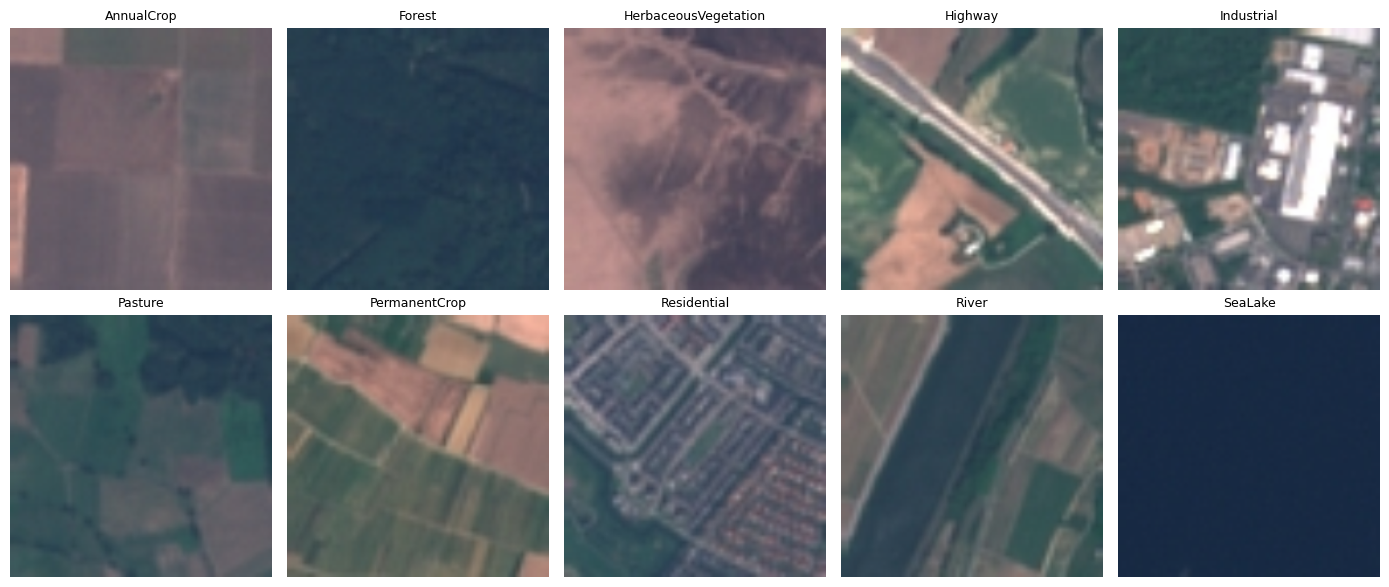

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
shown = {}
for img, lbl in full_dataset:
    if lbl not in shown:
        shown[lbl] = img
    if len(shown) == num_classes:
        break

for i, ax in enumerate(axes.flat):
    img_display = shown[i].permute(1, 2, 0).numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(class_names[i], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
generator = torch.Generator().manual_seed(SEEDS[0])
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Train: 18900, Val: 4050, Test: 4050


## 2. Model builder

In [ ]:
def build_model(which_model, variant='finetune'):
    """which_model: 'CNN' or 'ViT'. variant: 'finetune' or 'frozen'."""
    if which_model == 'CNN':
        model = models.resnet50(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_name = 'fc'
    else:
        model = models.vit_b_32(weights='DEFAULT')
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        head_name = 'heads'

    if variant == 'frozen':
        for name, param in model.named_parameters():
            if head_name not in name:
                param.requires_grad = False

    return model.to(device)

## 3. Training and evaluation functions

In [ ]:
criterion = nn.CrossEntropyLoss()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_model(model, train_loader, val_loader, epochs=10, lr=5e-5, weight_decay=0.0, patience=3):
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state, epochs_no_improve = 0.0, None, 0

    for epoch in range(epochs):
        model.train()
        train_running_loss, train_running_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_running_correct += (predicted == labels).sum().item()

        train_loss = train_running_loss / train_total
        train_acc = train_running_correct / train_total

        model.eval()
        val_running_loss, val_running_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_running_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_acc = val_running_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f'  Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_true = [], []
    start = time.time()
    n_images = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        n_images += inputs.size(0)
    elapsed = time.time() - start
    acc = accuracy_score(all_true, all_preds)
    macro_f1 = f1_score(all_true, all_preds, average='macro')
    cm = confusion_matrix(all_true, all_preds)
    latency_ms_per_image = (elapsed / n_images) * 1000
    return {'accuracy': acc, 'macro_f1': macro_f1, 'confusion_matrix': cm, 'latency_ms_per_image': latency_ms_per_image}

def make_subset_loader(dataset, fraction, batch_size, seed):
    n = len(dataset)
    n_subset = max(1, int(n * fraction))
    gen = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n, generator=gen)[:n_subset]
    subset = Subset(dataset, idx.tolist())
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

## 4. CNN track

### 4.1 Baseline + compute metrics

We first train ResNet-50 using the full training dataset to establish a baseline for its performance. We record the main evaluation metrics as well as training time, number of parameters and inference latency for comparison with the ViT model.


In [ ]:
WHICH_MODEL = 'CNN'
cnn_baseline_results = []
cnn_baseline_models = {}
cnn_baseline_histories = {}

for seed in SEEDS:
    print(f'\n========== CNN baseline | seed {seed} ==========')
    set_seed(seed)
    m = build_model('CNN')
    params = count_params(m)
    start = time.time()
    m, history = train_one_model(m, train_loader, val_loader, epochs=EPOCHS, lr=LR)
    train_time = time.time() - start
    res = evaluate_model(m, test_loader)

    cnn_baseline_results.append({
        'model': 'CNN', 'seed': seed, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1'],
        'params': params, 'train_time_s': train_time, 'latency_ms_per_image': res['latency_ms_per_image'],
    })
    cnn_baseline_models[seed] = m
    cnn_baseline_histories[seed] = history

cnn_baseline_df = pd.DataFrame(cnn_baseline_results)
cnn_baseline_df.to_csv('baseline_results_CNN.csv', index=False)
cnn_baseline_df


========== CNN baseline | seed 42 ==========
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


  Epoch 1/8: Train Loss=0.5013, Train Acc=0.8696, Val Loss=0.0855, Val Acc=0.9760
  Epoch 2/8: Train Loss=0.0862, Train Acc=0.9721, Val Loss=0.0571, Val Acc=0.9785
  Epoch 3/8: Train Loss=0.0470, Train Acc=0.9860, Val Loss=0.0553, Val Acc=0.9812
  Epoch 4/8: Train Loss=0.0289, Train Acc=0.9905, Val Loss=0.0518, Val Acc=0.9822
  Epoch 5/8: Train Loss=0.0249, Train Acc=0.9931, Val Loss=0.0613, Val Acc=0.9798
  Epoch 6/8: Train Loss=0.0172, Train Acc=0.9944, Val Loss=0.0595, Val Acc=0.9820
  Epoch 7/8: Train Loss=0.0131, Train Acc=0.9962, Val Loss=0.0588, Val Acc=0.9827
  Epoch 8/8: Train Loss=0.0152, Train Acc=0.9954, Val Loss=0.0755, Val Acc=0.9765

========== CNN baseline | seed 123 ==========
  Epoch 1/8: Train Loss=0.5070, Train Acc=0.8731, Val Loss=0.0794, Val Acc=0.9775
  Epoch 2/8: Train Loss=0.0836, Train Acc=0.9738, Val Loss=0.0580, Val Acc=0.9812
  Epoch 3/8: Train Loss=0.0461, Train Acc=0.9857, Val Loss=0.0582, Val Acc=0.9812
  Epoch 4/8: Train Loss=0.0297, Train Acc=0.9911, V

,model,seed,accuracy,macro_f1,params,train_time_s,latency_ms_per_image
0,CNN,42,0.983457,0.983303,23528522,1727.276842,3.291096
1,CNN,123,0.979259,0.978585,23528522,1081.607615,3.403171


In [ ]:
cnn_baseline_summary = cnn_baseline_df.groupby('model').agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
    params=('params', 'first'), train_time_s_mean=('train_time_s', 'mean'),
    latency_ms_per_image_mean=('latency_ms_per_image', 'mean'),
).reset_index()
cnn_baseline_summary.to_csv('baseline_summary_CNN.csv', index=False)
cnn_baseline_summary

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,params,train_time_s_mean,latency_ms_per_image_mean
0,CNN,0.981358,0.002968,0.980944,0.003336,23528522,1404.442228,3.347133


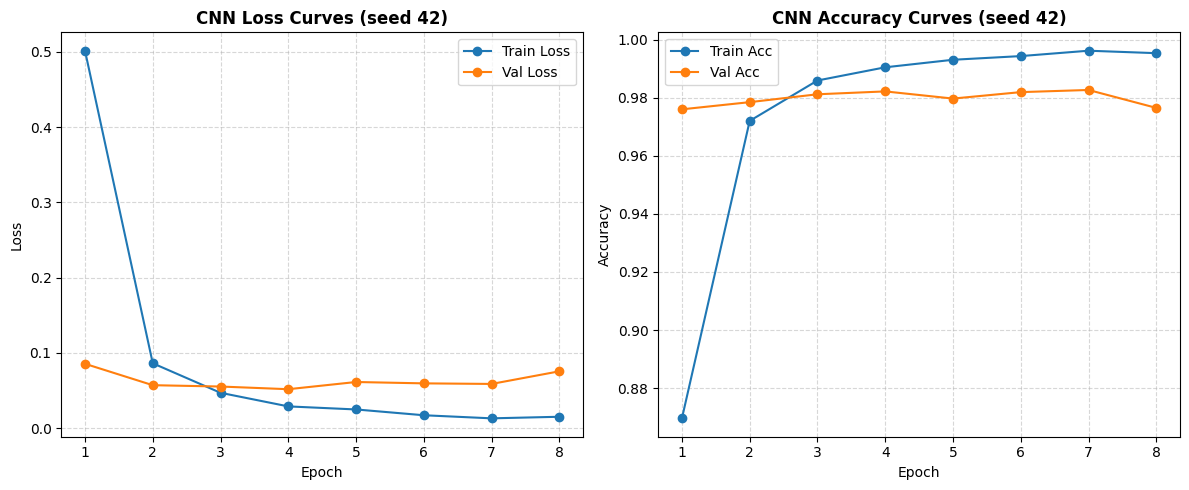

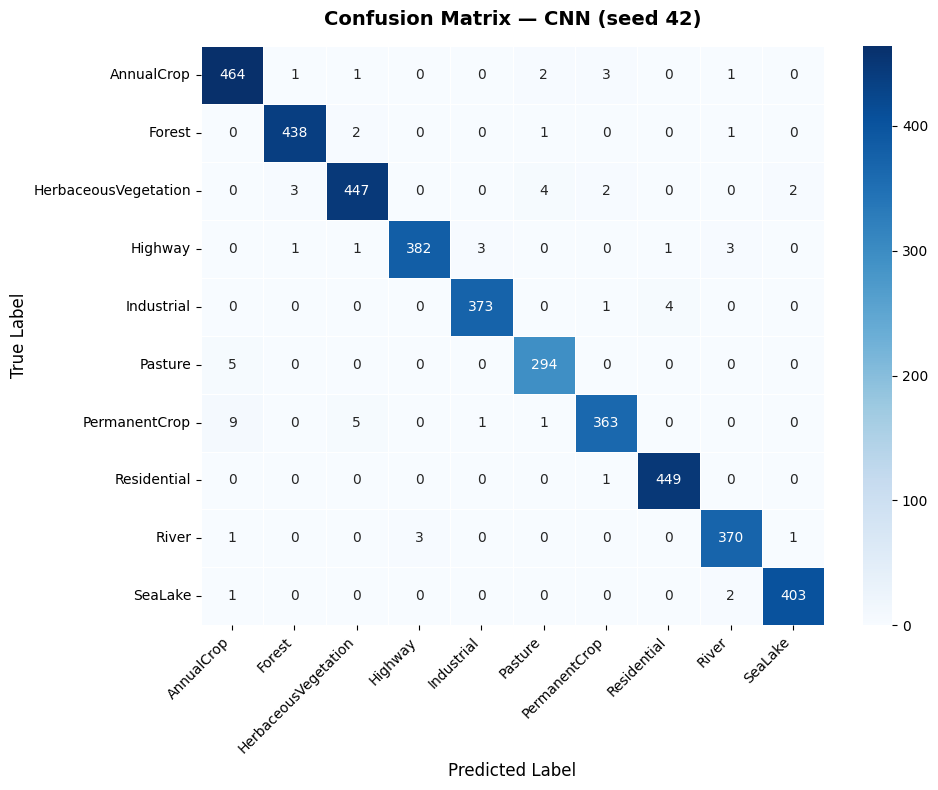

In [ ]:
rep_seed = SEEDS[0]
rep_model = cnn_baseline_models[rep_seed]
rep_history = cnn_baseline_histories[rep_seed]
rep_res = evaluate_model(rep_model, test_loader)

epochs = range(1, len(rep_history['train_loss']) + 1)

# 1. Dual Plot: Loss & Accuracy Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left Subplot: Loss Curves
ax1.plot(epochs, rep_history['train_loss'], marker='o', label='Train Loss')
ax1.plot(epochs, rep_history['val_loss'], marker='o', label='Val Loss')
ax1.set_title(f'CNN Loss Curves (seed {rep_seed})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Subplot: Accuracy Curves
ax2.plot(epochs, rep_history['train_acc'], marker='o', label='Train Acc')
ax2.plot(epochs, rep_history['val_acc'], marker='o', label='Val Acc')
ax2.set_title(f'CNN Accuracy Curves (seed {rep_seed})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('loss_accuracy_curves_CNN.png', dpi=150)
plt.show()


# 2. Enhanced Seaborn Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    rep_res['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — CNN (seed {rep_seed})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_CNN.png', dpi=150)
plt.show()

### 4.2 Data-efficiency crossover

This experiment looks at how ResNet-50 performs when less training data is available. We train the model using 50% and 10% of the original training data and compare the results with the full data baseline.


In [ ]:
DATA_FRACTIONS = [0.50, 0.10]
cnn_de_results = []

for seed in SEEDS:
    set_seed(seed)
    for fraction in DATA_FRACTIONS:
        print(f'\n=== CNN | seed {seed} | fraction {fraction} ===')
        sub_loader = make_subset_loader(train_data, fraction, BATCH_SIZE, seed)
        m = build_model('CNN')
        m, _ = train_one_model(m, sub_loader, val_loader, epochs=DE_EPOCHS, lr=LR)
        res = evaluate_model(m, test_loader)
        cnn_de_results.append({
            'model': 'CNN', 'seed': seed, 'fraction': fraction,
            'accuracy': res['accuracy'], 'macro_f1': res['macro_f1'],
        })
        pd.DataFrame(cnn_de_results).to_csv('data_efficiency_CNN.csv', index=False)

cnn_de_df = pd.DataFrame(cnn_de_results)
cnn_de_df


=== CNN | seed 42 | fraction 0.5 ===
  Epoch 1/5: Train Loss=0.8445, Train Acc=0.7858, Val Loss=0.1311, Val Acc=0.9654
  Epoch 2/5: Train Loss=0.1245, Train Acc=0.9622, Val Loss=0.0881, Val Acc=0.9733
  Epoch 3/5: Train Loss=0.0656, Train Acc=0.9805, Val Loss=0.0790, Val Acc=0.9768
  Epoch 4/5: Train Loss=0.0446, Train Acc=0.9874, Val Loss=0.0724, Val Acc=0.9770
  Epoch 5/5: Train Loss=0.0277, Train Acc=0.9924, Val Loss=0.0781, Val Acc=0.9770

=== CNN | seed 42 | fraction 0.1 ===
  Epoch 1/5: Train Loss=2.0336, Train Acc=0.4201, Val Loss=1.8920, Val Acc=0.5319
  Epoch 2/5: Train Loss=1.1936, Train Acc=0.7815, Val Loss=0.8811, Val Acc=0.8353
  Epoch 3/5: Train Loss=0.5330, Train Acc=0.9090, Val Loss=0.3271, Val Acc=0.9222
  Epoch 4/5: Train Loss=0.1913, Train Acc=0.9598, Val Loss=0.2121, Val Acc=0.9412
  Epoch 5/5: Train Loss=0.0959, Train Acc=0.9810, Val Loss=0.1922, Val Acc=0.9432

=== CNN | seed 123 | fraction 0.5 ===
  Epoch 1/5: Train Loss=0.8728, Train Acc=0.7903, Val Loss=0.1334

,model,seed,fraction,accuracy,macro_f1
0,CNN,42,0.5,0.972593,0.971794
1,CNN,42,0.1,0.948395,0.947327
2,CNN,123,0.5,0.972346,0.971862
3,CNN,123,0.1,0.948642,0.947722


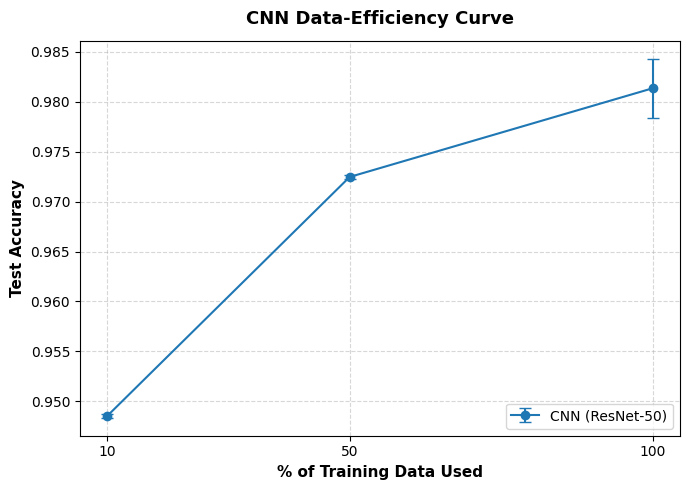

In [ ]:
# Aggregate results for 10% and 50%
cnn_de_summary = cnn_de_df.groupby(['model', 'fraction']).agg(
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std')
).reset_index()

# Pull 100% baseline performance dynamically from baseline summary
cnn_base_acc_mean = cnn_baseline_df['accuracy'].mean()
cnn_base_acc_std = cnn_baseline_df['accuracy'].std()

# Combine baseline (1.0) with fractions (0.10, 0.50)
plot_df = pd.concat([
    cnn_de_summary,
    pd.DataFrame([{
        'model': 'CNN',
        'fraction': 1.0,
        'accuracy_mean': cnn_base_acc_mean,
        'accuracy_std': cnn_base_acc_std
    }])
]).sort_values('fraction')

# Plot complete data-efficiency curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    plot_df['fraction'] * 100,
    plot_df['accuracy_mean'],
    yerr=plot_df['accuracy_std'],
    marker='o',
    capsize=4,
    linestyle='-',
    color='#1f77b4',
    label='CNN (ResNet-50)'
)

ax.set_xlabel('% of Training Data Used', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_title('CNN Data-Efficiency Curve', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks([10, 50, 100])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('data_efficiency_plot_CNN.png', dpi=150)
plt.show()

### 4.3 Robustness ablation

Here, we test the robustness of the trained ResNet-50 model by evaluating it on test images with different levels of noise and blur. The model is not retrained allowing us to see how its performance changes with corrupted inputs.


In [ ]:
from PIL import ImageFilter

NOISE_SEVERITIES = [0.0, 0.05, 0.10, 0.20, 0.30]
BLUR_SEVERITIES = [0, 1, 2, 4, 6]

def add_noise_to_tensor(img_tensor, severity):
    if severity == 0:
        return img_tensor
    noise = torch.randn_like(img_tensor) * severity
    return torch.clamp(img_tensor + noise, -3, 3)

def add_blur_to_tensor(img_tensor, radius):
    if radius == 0:
        return img_tensor
    pil_img = transforms.ToPILImage()(img_tensor)
    blurred = pil_img.filter(ImageFilter.GaussianBlur(radius))
    return transforms.ToTensor()(blurred)

@torch.no_grad()
def evaluate_with_corruption(model, loader, corruption_fn, severity):
    model.eval()
    all_preds, all_true = [], []
    for inputs, labels in loader:
        corrupted = torch.stack([corruption_fn(img, severity) for img in inputs])
        corrupted, labels = corrupted.to(device), labels.to(device)
        outputs = model(corrupted)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
    return accuracy_score(all_true, all_preds)

cnn_rob_results = []
for corruption_name, severities, corruption_fn in [
    ('gaussian_noise', NOISE_SEVERITIES, add_noise_to_tensor),
    ('blur', BLUR_SEVERITIES, add_blur_to_tensor),
]:
    for severity in severities:
        for seed in SEEDS:
            acc = evaluate_with_corruption(cnn_baseline_models[seed], test_loader, corruption_fn, severity)
            cnn_rob_results.append({'model': 'CNN', 'seed': seed, 'corruption': corruption_name, 'severity': severity, 'accuracy': acc})
        print(corruption_name, severity, 'done')

cnn_rob_df = pd.DataFrame(cnn_rob_results)
cnn_rob_df.to_csv('robustness_CNN.csv', index=False)
cnn_rob_df

gaussian_noise 0.0 done
gaussian_noise 0.05 done
gaussian_noise 0.1 done
gaussian_noise 0.2 done
gaussian_noise 0.3 done
blur 0 done
blur 1 done
blur 2 done
blur 4 done
blur 6 done


,model,seed,corruption,severity,accuracy
0,CNN,42,gaussian_noise,0.00,0.983457
1,CNN,123,gaussian_noise,0.00,0.979259
2,CNN,42,gaussian_noise,0.05,0.566914
3,CNN,123,gaussian_noise,0.05,0.695309
4,CNN,42,gaussian_noise,0.10,0.188148
5,CNN,123,gaussian_noise,0.10,0.367901
6,CNN,42,gaussian_noise,0.20,0.116543
7,CNN,123,gaussian_noise,0.20,0.093580
8,CNN,42,gaussian_noise,0.30,0.116543
9,CNN,123,gaussian_noise,0.30,0.116543


In [ ]:
cnn_rob_summary = cnn_rob_df.groupby(['model', 'corruption', 'severity']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
).reset_index()
cnn_rob_summary.to_csv('robustness_summary_CNN.csv', index=False)
cnn_rob_summary

,model,corruption,severity,accuracy_mean,accuracy_std
0,CNN,blur,0.00,0.981358,0.002968
1,CNN,blur,1.00,0.201358,0.025316
2,CNN,blur,2.00,0.212963,0.060235
3,CNN,blur,4.00,0.170247,0.029506
4,CNN,blur,6.00,0.159383,0.011698
5,CNN,gaussian_noise,0.00,0.981358,0.002968
6,CNN,gaussian_noise,0.05,0.631111,0.090789
7,CNN,gaussian_noise,0.10,0.278025,0.127105
8,CNN,gaussian_noise,0.20,0.105062,0.016237
9,CNN,gaussian_noise,0.30,0.116543,0.000000


### 4.4 Hyperparameter sweeps

This experiment tests how different training settings affect ResNet-50. We vary the learning rate, weight decay and batch size while keeping the other settings the same allowing us to compare the effect of each hyperparameter.


In [ ]:
# Learning rate sweep
LR_VALUES = [1e-4, 5e-5, 1e-5]
cnn_lr_sweep_results = []
set_seed(SEEDS[0])

for lr in LR_VALUES:
    print(f'\n=== CNN LR sweep: lr={lr} ===')
    m = build_model('CNN')
    m, _ = train_one_model(m, train_loader, val_loader, epochs=HP_EPOCHS, lr=lr)
    res = evaluate_model(m, test_loader)
    cnn_lr_sweep_results.append({'model': 'CNN', 'lr': lr, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

cnn_lr_sweep_df = pd.DataFrame(cnn_lr_sweep_results)
cnn_lr_sweep_df.to_csv('lr_sweep_CNN.csv', index=False)
cnn_lr_sweep_df


=== CNN LR sweep: lr=0.0001 ===
  Epoch 1/4: Train Loss=0.3432, Train Acc=0.9068, Val Loss=0.0789, Val Acc=0.9746
  Epoch 2/4: Train Loss=0.0758, Train Acc=0.9753, Val Loss=0.0491, Val Acc=0.9842
  Epoch 3/4: Train Loss=0.0392, Train Acc=0.9879, Val Loss=0.0742, Val Acc=0.9780
  Epoch 4/4: Train Loss=0.0269, Train Acc=0.9919, Val Loss=0.0506, Val Acc=0.9830

=== CNN LR sweep: lr=5e-05 ===
  Epoch 1/4: Train Loss=0.4978, Train Acc=0.8697, Val Loss=0.0993, Val Acc=0.9689
  Epoch 2/4: Train Loss=0.0789, Train Acc=0.9744, Val Loss=0.0795, Val Acc=0.9731
  Epoch 3/4: Train Loss=0.0403, Train Acc=0.9879, Val Loss=0.1155, Val Acc=0.9635
  Epoch 4/4: Train Loss=0.0278, Train Acc=0.9912, Val Loss=0.0702, Val Acc=0.9780

=== CNN LR sweep: lr=1e-05 ===
  Epoch 1/4: Train Loss=1.4568, Train Acc=0.6413, Val Loss=0.5650, Val Acc=0.8896
  Epoch 2/4: Train Loss=0.3136, Train Acc=0.9227, Val Loss=0.1448, Val Acc=0.9635
  Epoch 3/4: Train Loss=0.1477, Train Acc=0.9573, Val Loss=0.0963, Val Acc=0.9731
 

,model,lr,accuracy,macro_f1
0,CNN,0.00010,0.978519,0.978237
1,CNN,0.00005,0.979259,0.978657
2,CNN,0.00001,0.972840,0.972261


In [ ]:
# Weight decay sweep
WEIGHT_DECAY_VALUES = [0.0, 0.01, 0.1]
cnn_wd_results = []
set_seed(SEEDS[0])

for wd in WEIGHT_DECAY_VALUES:
    print(f'\n=== CNN weight decay={wd} ===')
    m = build_model('CNN')
    m, _ = train_one_model(m, train_loader, val_loader, epochs=HP_EPOCHS, lr=LR, weight_decay=wd)
    res = evaluate_model(m, test_loader)
    cnn_wd_results.append({'model': 'CNN', 'weight_decay': wd, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

cnn_wd_df = pd.DataFrame(cnn_wd_results)
cnn_wd_df.to_csv('weight_decay_sweep_CNN.csv', index=False)
cnn_wd_df


=== CNN weight decay=0.0 ===
  Epoch 1/4: Train Loss=0.5014, Train Acc=0.8697, Val Loss=0.0869, Val Acc=0.9763
  Epoch 2/4: Train Loss=0.0867, Train Acc=0.9730, Val Loss=0.0558, Val Acc=0.9802
  Epoch 3/4: Train Loss=0.0497, Train Acc=0.9839, Val Loss=0.0605, Val Acc=0.9783
  Epoch 4/4: Train Loss=0.0289, Train Acc=0.9919, Val Loss=0.0508, Val Acc=0.9830

=== CNN weight decay=0.01 ===
  Epoch 1/4: Train Loss=0.4945, Train Acc=0.8725, Val Loss=0.1066, Val Acc=0.9664
  Epoch 2/4: Train Loss=0.0792, Train Acc=0.9747, Val Loss=0.0696, Val Acc=0.9763
  Epoch 3/4: Train Loss=0.0369, Train Acc=0.9898, Val Loss=0.1038, Val Acc=0.9677
  Epoch 4/4: Train Loss=0.0286, Train Acc=0.9915, Val Loss=0.0604, Val Acc=0.9815

=== CNN weight decay=0.1 ===
  Epoch 1/4: Train Loss=0.5054, Train Acc=0.8700, Val Loss=0.0816, Val Acc=0.9751
  Epoch 2/4: Train Loss=0.0847, Train Acc=0.9738, Val Loss=0.0689, Val Acc=0.9773
  Epoch 3/4: Train Loss=0.0454, Train Acc=0.9869, Val Loss=0.0530, Val Acc=0.9835
  Epoch

,model,weight_decay,accuracy,macro_f1
0,CNN,0.00,0.978765,0.978357
1,CNN,0.01,0.979506,0.978935
2,CNN,0.10,0.980000,0.979392


In [ ]:
# Batch size sweep
BATCH_SIZE_VALUES = [32, 64]
cnn_bs_results = []
set_seed(SEEDS[0])

for bs in BATCH_SIZE_VALUES:
    print(f'\n=== CNN batch size={bs} ===')
    bs_train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_data, batch_size=bs, shuffle=False)
    bs_test_loader = DataLoader(test_data, batch_size=bs, shuffle=False)
    m = build_model('CNN')
    m, _ = train_one_model(m, bs_train_loader, bs_val_loader, epochs=HP_EPOCHS, lr=LR)
    res = evaluate_model(m, bs_test_loader)
    cnn_bs_results.append({'model': 'CNN', 'batch_size': bs, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

cnn_bs_df = pd.DataFrame(cnn_bs_results)
cnn_bs_df.to_csv('batch_size_sweep_CNN.csv', index=False)
cnn_bs_df


=== CNN batch size=32 ===
  Epoch 1/4: Train Loss=0.4311, Train Acc=0.8816, Val Loss=0.0871, Val Acc=0.9768
  Epoch 2/4: Train Loss=0.1026, Train Acc=0.9677, Val Loss=0.0608, Val Acc=0.9783
  Epoch 3/4: Train Loss=0.0578, Train Acc=0.9814, Val Loss=0.0564, Val Acc=0.9815
  Epoch 4/4: Train Loss=0.0367, Train Acc=0.9886, Val Loss=0.0498, Val Acc=0.9849

=== CNN batch size=64 ===
  Epoch 1/4: Train Loss=0.4990, Train Acc=0.8696, Val Loss=0.0859, Val Acc=0.9733
  Epoch 2/4: Train Loss=0.0809, Train Acc=0.9734, Val Loss=0.0737, Val Acc=0.9758
  Epoch 3/4: Train Loss=0.0388, Train Acc=0.9886, Val Loss=0.0747, Val Acc=0.9783
  Epoch 4/4: Train Loss=0.0311, Train Acc=0.9908, Val Loss=0.0647, Val Acc=0.9810


,model,batch_size,accuracy,macro_f1
0,CNN,32,0.981728,0.981157
1,CNN,64,0.979506,0.979172


### 4.5 Ablations

This experiment examines the effect of different training choices on ResNet-50. We compare a frozen pretrained backbone with full fine-tuning and also compare training with and without data augmentation.


In [ ]:
# Transfer-learning ablation: frozen vs fine-tune
TRANSFER_VARIANTS = ['frozen', 'finetune']
cnn_transfer_results = []
set_seed(SEEDS[0])

for variant in TRANSFER_VARIANTS:
    print(f'\n=== CNN transfer-learning variant: {variant} ===')
    m = build_model('CNN', variant=variant)
    m, _ = train_one_model(m, train_loader, val_loader, epochs=HP_EPOCHS, lr=LR)
    res = evaluate_model(m, test_loader)
    cnn_transfer_results.append({'model': 'CNN', 'variant': variant, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

cnn_transfer_df = pd.DataFrame(cnn_transfer_results)
cnn_transfer_df.to_csv('transfer_learning_ablation_CNN.csv', index=False)
cnn_transfer_df


=== CNN transfer-learning variant: frozen ===
  Epoch 1/4: Train Loss=1.9376, Train Acc=0.5198, Val Loss=1.6308, Val Acc=0.7173
  Epoch 2/4: Train Loss=1.4328, Train Acc=0.7391, Val Loss=1.2471, Val Acc=0.7756
  Epoch 3/4: Train Loss=1.1374, Train Acc=0.7852, Val Loss=1.0270, Val Acc=0.8074
  Epoch 4/4: Train Loss=0.9630, Train Acc=0.8023, Val Loss=0.8769, Val Acc=0.8267

=== CNN transfer-learning variant: finetune ===
  Epoch 1/4: Train Loss=0.4982, Train Acc=0.8708, Val Loss=0.0820, Val Acc=0.9763
  Epoch 2/4: Train Loss=0.0792, Train Acc=0.9748, Val Loss=0.0682, Val Acc=0.9780
  Epoch 3/4: Train Loss=0.0396, Train Acc=0.9881, Val Loss=0.0898, Val Acc=0.9721
  Epoch 4/4: Train Loss=0.0290, Train Acc=0.9906, Val Loss=0.0658, Val Acc=0.9802


,model,variant,accuracy,macro_f1
0,CNN,frozen,0.816543,0.805488
1,CNN,finetune,0.979012,0.978611


In [ ]:
# Data augmentation ablation
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
])

transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    augment_transform,
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset_aug = datasets.EuroSAT(root='./data', download=False, transform=transform_aug)
train_data_aug = Subset(full_dataset_aug, train_data.indices)

cnn_aug_results = []
set_seed(SEEDS[0])

for use_aug in [False, True]:
    print(f"\n=== CNN augmentation={'on' if use_aug else 'off'} ===")
    loader = DataLoader(train_data_aug if use_aug else train_data, batch_size=BATCH_SIZE, shuffle=True)
    m = build_model('CNN')
    m, _ = train_one_model(m, loader, val_loader, epochs=HP_EPOCHS, lr=LR)
    res = evaluate_model(m, test_loader)
    cnn_aug_results.append({'model': 'CNN', 'augmentation': use_aug, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

cnn_aug_df = pd.DataFrame(cnn_aug_results)
cnn_aug_df.to_csv('augmentation_ablation_CNN.csv', index=False)
cnn_aug_df


=== CNN augmentation=off ===
  Epoch 1/4: Train Loss=0.5021, Train Acc=0.8692, Val Loss=0.0902, Val Acc=0.9736
  Epoch 2/4: Train Loss=0.0869, Train Acc=0.9725, Val Loss=0.0561, Val Acc=0.9795
  Epoch 3/4: Train Loss=0.0487, Train Acc=0.9852, Val Loss=0.0562, Val Acc=0.9807
  Epoch 4/4: Train Loss=0.0273, Train Acc=0.9922, Val Loss=0.0555, Val Acc=0.9817

=== CNN augmentation=on ===
  Epoch 1/4: Train Loss=0.5184, Train Acc=0.8627, Val Loss=0.0908, Val Acc=0.9736
  Epoch 2/4: Train Loss=0.1078, Train Acc=0.9667, Val Loss=0.0708, Val Acc=0.9760
  Epoch 3/4: Train Loss=0.0763, Train Acc=0.9753, Val Loss=0.0554, Val Acc=0.9802
  Epoch 4/4: Train Loss=0.0565, Train Acc=0.9819, Val Loss=0.0570, Val Acc=0.9798


,model,augmentation,accuracy,macro_f1
0,CNN,False,0.981975,0.981526
1,CNN,True,0.980247,0.979801


## 5. ViT track

### 5.1 Baseline + compute metrics

We first train ViT-B/32 using the full training dataset to establish a baseline for its performance. The same evaluation metrics and computational measures are recorded so that the results can be compared fairly with ResNet-50.


In [ ]:
SEEDS = [42, 123]
WHICH_MODEL = 'ViT'
vit_baseline_results = []
vit_baseline_models = {}
vit_baseline_histories = {}

for seed in SEEDS:
    print(f'\n========== ViT baseline | seed {seed} ==========')
    set_seed(seed)
    m = build_model('ViT')
    params = count_params(m)
    start = time.time()
    m, history = train_one_model(m, train_loader, val_loader, epochs=EPOCHS, lr=LR)
    train_time = time.time() - start
    res = evaluate_model(m, test_loader)

    vit_baseline_results.append({
        'model': 'ViT', 'seed': seed, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1'],
        'params': params, 'train_time_s': train_time, 'latency_ms_per_image': res['latency_ms_per_image'],
    })
    vit_baseline_models[seed] = m
    vit_baseline_histories[seed] = history

vit_baseline_df = pd.DataFrame(vit_baseline_results)
vit_baseline_df.to_csv('baseline_results_ViT.csv', index=False)
vit_baseline_df


========== ViT baseline | seed 42 ==========
Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth


100%|██████████| 337M/337M [00:02<00:00, 166MB/s]


  Epoch 1/8: Train Loss=0.2122, Train Acc=0.9335, Val Loss=0.1153, Val Acc=0.9617
  Epoch 2/8: Train Loss=0.0719, Train Acc=0.9759, Val Loss=0.1251, Val Acc=0.9620
  Epoch 3/8: Train Loss=0.0537, Train Acc=0.9826, Val Loss=0.1457, Val Acc=0.9489
  Epoch 4/8: Train Loss=0.0430, Train Acc=0.9856, Val Loss=0.0778, Val Acc=0.9723
  Epoch 5/8: Train Loss=0.0279, Train Acc=0.9910, Val Loss=0.1340, Val Acc=0.9640
  Epoch 6/8: Train Loss=0.0315, Train Acc=0.9899, Val Loss=0.0943, Val Acc=0.9716
  Epoch 7/8: Train Loss=0.0248, Train Acc=0.9920, Val Loss=0.1092, Val Acc=0.9681
  Early stopping at epoch 7

========== ViT baseline | seed 123 ==========
  Epoch 1/8: Train Loss=0.2132, Train Acc=0.9329, Val Loss=0.1664, Val Acc=0.9440
  Epoch 2/8: Train Loss=0.0720, Train Acc=0.9769, Val Loss=0.1527, Val Acc=0.9474
  Epoch 3/8: Train Loss=0.0477, Train Acc=0.9848, Val Loss=0.0743, Val Acc=0.9748
  Epoch 4/8: Train Loss=0.0355, Train Acc=0.9886, Val Loss=0.1035, Val Acc=0.9681
  Epoch 5/8: Train Loss

,model,seed,accuracy,macro_f1,params,train_time_s,latency_ms_per_image
0,ViT,42,0.969877,0.969272,87462922,1281.183743,3.277189
1,ViT,123,0.976543,0.975750,87462922,1469.796957,3.246093


In [ ]:
vit_baseline_summary = vit_baseline_df.groupby('model').agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
    params=('params', 'first'), train_time_s_mean=('train_time_s', 'mean'),
    latency_ms_per_image_mean=('latency_ms_per_image', 'mean'),
).reset_index()
vit_baseline_summary.to_csv('baseline_summary_ViT.csv', index=False)
vit_baseline_summary

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,params,train_time_s_mean,latency_ms_per_image_mean
0,ViT,0.97321,0.004714,0.972511,0.00458,87462922,1375.49035,3.261641


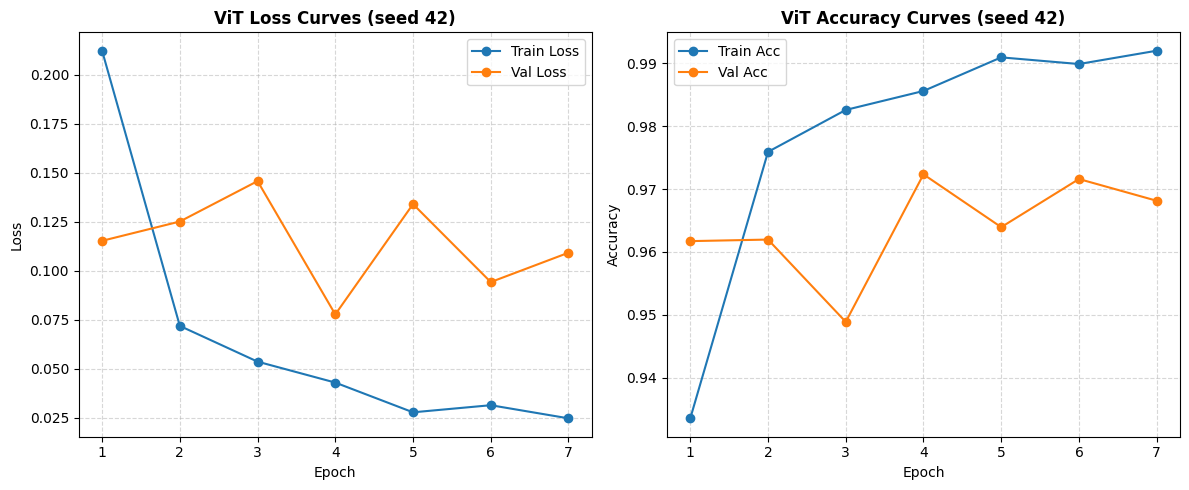

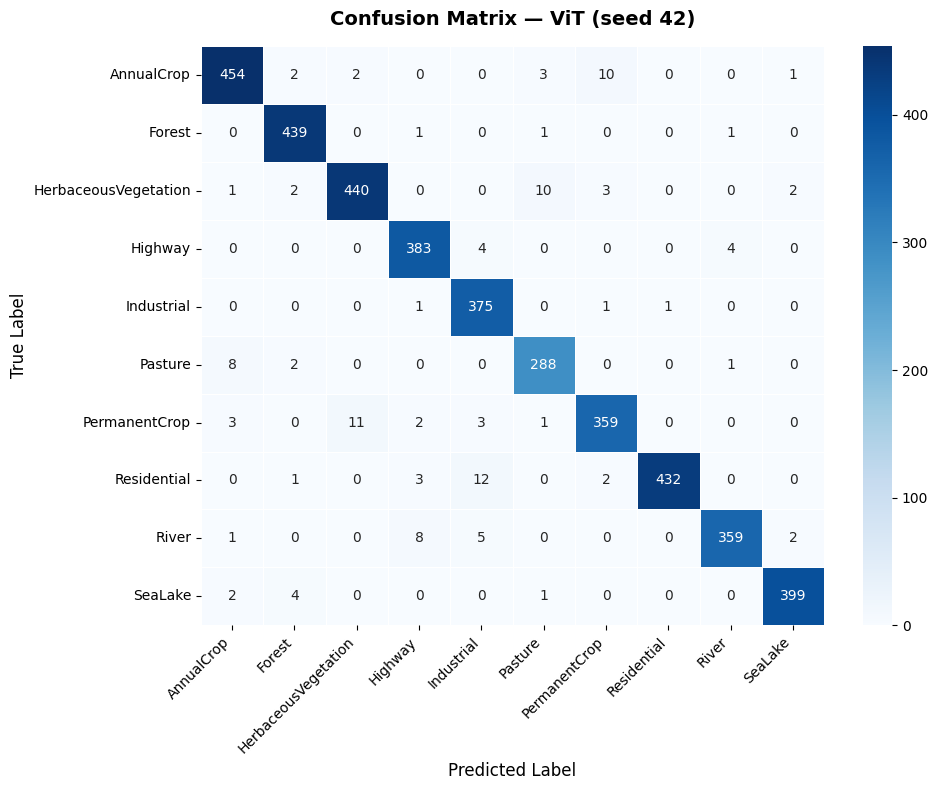

In [ ]:
rep_seed = SEEDS[0]
rep_model = vit_baseline_models[rep_seed]
rep_history = vit_baseline_histories[rep_seed]
rep_res = evaluate_model(rep_model, test_loader)

epochs = range(1, len(rep_history['train_loss']) + 1)

# 1. Dual Plot: Loss & Accuracy Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left Subplot: Loss Curves
ax1.plot(epochs, rep_history['train_loss'], marker='o', label='Train Loss')
ax1.plot(epochs, rep_history['val_loss'], marker='o', label='Val Loss')
ax1.set_title(f'ViT Loss Curves (seed {rep_seed})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Subplot: Accuracy Curves
ax2.plot(epochs, rep_history['train_acc'], marker='o', label='Train Acc')
ax2.plot(epochs, rep_history['val_acc'], marker='o', label='Val Acc')
ax2.set_title(f'ViT Accuracy Curves (seed {rep_seed})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('loss_accuracy_curves_ViT.png', dpi=150)
plt.show()


# 2. Enhanced Seaborn Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    rep_res['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — ViT (seed {rep_seed})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_ViT.png', dpi=150)
plt.show()

### 5.2 Data-efficiency crossover

This experiment looks at how ViT-B/32 performs when less training data is available. We train the model using 50% and 10% of the original training data and compare the results with the full data baseline.


In [ ]:
DATA_FRACTIONS = [0.50, 0.10]
vit_de_results = []

for seed in SEEDS:
    set_seed(seed)
    for fraction in DATA_FRACTIONS:
        print(f'\n=== ViT | seed {seed} | fraction {fraction} ===')
        sub_loader = make_subset_loader(train_data, fraction, BATCH_SIZE, seed)
        m = build_model('ViT')
        m, _ = train_one_model(m, sub_loader, val_loader, epochs=DE_EPOCHS, lr=LR)
        res = evaluate_model(m, test_loader)
        vit_de_results.append({
            'model': 'ViT', 'seed': seed, 'fraction': fraction,
            'accuracy': res['accuracy'], 'macro_f1': res['macro_f1'],
        })
        pd.DataFrame(vit_de_results).to_csv('data_efficiency_ViT.csv', index=False)

vit_de_df = pd.DataFrame(vit_de_results)
vit_de_df


=== ViT | seed 42 | fraction 0.5 ===
  Epoch 1/5: Train Loss=0.2948, Train Acc=0.9103, Val Loss=0.1098, Val Acc=0.9654
  Epoch 2/5: Train Loss=0.0823, Train Acc=0.9740, Val Loss=0.1316, Val Acc=0.9575
  Epoch 3/5: Train Loss=0.0453, Train Acc=0.9854, Val Loss=0.0840, Val Acc=0.9728
  Epoch 4/5: Train Loss=0.0435, Train Acc=0.9867, Val Loss=0.1840, Val Acc=0.9472
  Epoch 5/5: Train Loss=0.0435, Train Acc=0.9843, Val Loss=0.0784, Val Acc=0.9753

=== ViT | seed 42 | fraction 0.1 ===
  Epoch 1/5: Train Loss=0.7657, Train Acc=0.7852, Val Loss=0.2331, Val Acc=0.9311
  Epoch 2/5: Train Loss=0.1442, Train Acc=0.9608, Val Loss=0.2554, Val Acc=0.9183
  Epoch 3/5: Train Loss=0.0981, Train Acc=0.9714, Val Loss=0.1264, Val Acc=0.9610
  Epoch 4/5: Train Loss=0.0335, Train Acc=0.9915, Val Loss=0.1449, Val Acc=0.9519
  Epoch 5/5: Train Loss=0.0694, Train Acc=0.9804, Val Loss=0.3207, Val Acc=0.8993

=== ViT | seed 123 | fraction 0.5 ===
  Epoch 1/5: Train Loss=0.2985, Train Acc=0.9121, Val Loss=0.1541

,model,seed,fraction,accuracy,macro_f1
0,ViT,42,0.5,0.969136,0.968741
1,ViT,42,0.1,0.954815,0.954176
2,ViT,123,0.5,0.964938,0.964489
3,ViT,123,0.1,0.959506,0.958500


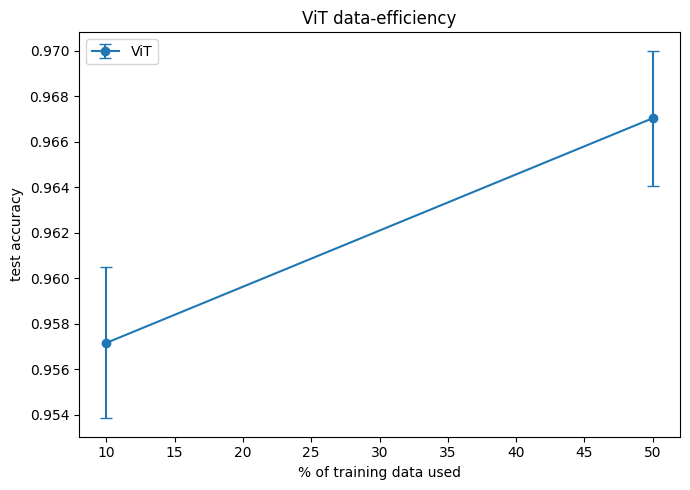

In [ ]:
vit_de_summary = vit_de_df.groupby(['model', 'fraction']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
).reset_index()
vit_de_summary.to_csv('data_efficiency_summary_ViT.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 5))
sub = vit_de_summary.sort_values('fraction')
ax.errorbar(sub['fraction'] * 100, sub['accuracy_mean'], yerr=sub['accuracy_std'], marker='o', capsize=4, label='ViT')
ax.set_xlabel('% of training data used')
ax.set_ylabel('test accuracy')
ax.set_title('ViT data-efficiency')
ax.legend()
plt.tight_layout()
plt.savefig('data_efficiency_plot_ViT.png', dpi=150)
plt.show()

### 5.3 Robustness ablation

Here, we test the robustness of the trained ViT-B/32 model by evaluating it on test images with different levels of noise and blur. The model is not retrained so we can see how its performance changes when the input images are corrupted.


In [ ]:
from PIL import ImageFilter

NOISE_SEVERITIES = [0.0, 0.05, 0.10, 0.20, 0.30]
BLUR_SEVERITIES = [0, 1, 2, 4, 6]

def add_noise_to_tensor(img_tensor, severity):
    if severity == 0:
        return img_tensor
    noise = torch.randn_like(img_tensor) * severity
    return torch.clamp(img_tensor + noise, -3, 3)

def add_blur_to_tensor(img_tensor, radius):
    if radius == 0:
        return img_tensor
    pil_img = transforms.ToPILImage()(img_tensor)
    blurred = pil_img.filter(ImageFilter.GaussianBlur(radius))
    return transforms.ToTensor()(blurred)

@torch.no_grad()
def evaluate_with_corruption(model, loader, corruption_fn, severity):
    model.eval()
    all_preds, all_true = [], []
    for inputs, labels in loader:
        corrupted = torch.stack([corruption_fn(img, severity) for img in inputs])
        corrupted, labels = corrupted.to(device), labels.to(device)
        outputs = model(corrupted)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
    return accuracy_score(all_true, all_preds)

vit_rob_results = []
for corruption_name, severities, corruption_fn in [
    ('gaussian_noise', NOISE_SEVERITIES, add_noise_to_tensor),
    ('blur', BLUR_SEVERITIES, add_blur_to_tensor),
]:
    for severity in severities:
        for seed in SEEDS:
            acc = evaluate_with_corruption(vit_baseline_models[seed], test_loader, corruption_fn, severity)
            vit_rob_results.append({'model': 'ViT', 'seed': seed, 'corruption': corruption_name, 'severity': severity, 'accuracy': acc})
        print(corruption_name, severity, 'done')

vit_rob_df = pd.DataFrame(vit_rob_results)
vit_rob_df.to_csv('robustness_ViT.csv', index=False)
vit_rob_df

gaussian_noise 0.0 done
gaussian_noise 0.05 done
gaussian_noise 0.1 done
gaussian_noise 0.2 done
gaussian_noise 0.3 done
blur 0 done
blur 1 done
blur 2 done
blur 4 done
blur 6 done


,model,seed,corruption,severity,accuracy
0,ViT,42,gaussian_noise,0.00,0.969877
1,ViT,123,gaussian_noise,0.00,0.976543
2,ViT,42,gaussian_noise,0.05,0.967901
3,ViT,123,gaussian_noise,0.05,0.975802
4,ViT,42,gaussian_noise,0.10,0.945926
5,ViT,123,gaussian_noise,0.10,0.971605
6,ViT,42,gaussian_noise,0.20,0.868889
7,ViT,123,gaussian_noise,0.20,0.920000
8,ViT,42,gaussian_noise,0.30,0.811111
9,ViT,123,gaussian_noise,0.30,0.841481


In [ ]:
vit_rob_summary = vit_rob_df.groupby(['model', 'corruption', 'severity']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
).reset_index()
vit_rob_summary.to_csv('robustness_summary_ViT.csv', index=False)
vit_rob_summary

,model,corruption,severity,accuracy_mean,accuracy_std
0,ViT,blur,0.00,0.973210,0.004714
1,ViT,blur,1.00,0.617284,0.003841
2,ViT,blur,2.00,0.540370,0.037538
3,ViT,blur,4.00,0.330000,0.005063
4,ViT,blur,6.00,0.206420,0.013968
5,ViT,gaussian_noise,0.00,0.973210,0.004714
6,ViT,gaussian_noise,0.05,0.971852,0.005587
7,ViT,gaussian_noise,0.10,0.958765,0.018158
8,ViT,gaussian_noise,0.20,0.894444,0.036141
9,ViT,gaussian_noise,0.30,0.826296,0.021475


### 5.4 Hyperparameter sweeps

This experiment tests how different training settings affect ViT-B/32. We vary the learning rate, weight decay and batch size while keeping the other settings the same allowing us to compare the effect of each hyperparameter.


In [ ]:
# Learning rate sweep
LR_VALUES = [1e-4, 5e-5, 1e-5]
vit_lr_sweep_results = []
set_seed(SEEDS[0])

for lr in LR_VALUES:
    print(f'\n=== ViT LR sweep: lr={lr} ===')
    m = build_model('ViT')
    m, _ = train_one_model(m, train_loader, val_loader, epochs=HP_EPOCHS, lr=lr)
    res = evaluate_model(m, test_loader)
    vit_lr_sweep_results.append({'model': 'ViT', 'lr': lr, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

vit_lr_sweep_df = pd.DataFrame(vit_lr_sweep_results)
vit_lr_sweep_df.to_csv('lr_sweep_ViT.csv', index=False)
vit_lr_sweep_df


=== ViT LR sweep: lr=0.0001 ===
  Epoch 1/4: Train Loss=0.2533, Train Acc=0.9153, Val Loss=0.1584, Val Acc=0.9459
  Epoch 2/4: Train Loss=0.1069, Train Acc=0.9659, Val Loss=0.0844, Val Acc=0.9731
  Epoch 3/4: Train Loss=0.0801, Train Acc=0.9730, Val Loss=0.1100, Val Acc=0.9664
  Epoch 4/4: Train Loss=0.0593, Train Acc=0.9799, Val Loss=0.1000, Val Acc=0.9657

=== ViT LR sweep: lr=5e-05 ===
  Epoch 1/4: Train Loss=0.2010, Train Acc=0.9393, Val Loss=0.1073, Val Acc=0.9637
  Epoch 2/4: Train Loss=0.0779, Train Acc=0.9750, Val Loss=0.0801, Val Acc=0.9738
  Epoch 3/4: Train Loss=0.0402, Train Acc=0.9880, Val Loss=0.0939, Val Acc=0.9706
  Epoch 4/4: Train Loss=0.0489, Train Acc=0.9838, Val Loss=0.0806, Val Acc=0.9731

=== ViT LR sweep: lr=1e-05 ===
  Epoch 1/4: Train Loss=0.3090, Train Acc=0.9211, Val Loss=0.0806, Val Acc=0.9778
  Epoch 2/4: Train Loss=0.0690, Train Acc=0.9802, Val Loss=0.0664, Val Acc=0.9800
  Epoch 3/4: Train Loss=0.0327, Train Acc=0.9905, Val Loss=0.0585, Val Acc=0.9810
 

,model,lr,accuracy,macro_f1
0,ViT,0.00010,0.964938,0.964453
1,ViT,0.00005,0.974074,0.973680
2,ViT,0.00001,0.980000,0.979344


In [ ]:
# Weight decay sweep
WEIGHT_DECAY_VALUES = [0.0, 0.01, 0.1]
vit_wd_results = []
set_seed(SEEDS[0])

for wd in WEIGHT_DECAY_VALUES:
    print(f'\n=== ViT weight decay={wd} ===')
    m = build_model('ViT')
    m, _ = train_one_model(m, train_loader, val_loader, epochs=HP_EPOCHS, lr=LR, weight_decay=wd)
    res = evaluate_model(m, test_loader)
    vit_wd_results.append({'model': 'ViT', 'weight_decay': wd, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

vit_wd_df = pd.DataFrame(vit_wd_results)
vit_wd_df.to_csv('weight_decay_sweep_ViT.csv', index=False)
vit_wd_df


=== ViT weight decay=0.0 ===
  Epoch 1/4: Train Loss=0.2122, Train Acc=0.9335, Val Loss=0.1153, Val Acc=0.9617
  Epoch 2/4: Train Loss=0.0719, Train Acc=0.9759, Val Loss=0.1251, Val Acc=0.9620
  Epoch 3/4: Train Loss=0.0537, Train Acc=0.9826, Val Loss=0.1457, Val Acc=0.9489
  Epoch 4/4: Train Loss=0.0430, Train Acc=0.9856, Val Loss=0.0778, Val Acc=0.9723

=== ViT weight decay=0.01 ===
  Epoch 1/4: Train Loss=0.2037, Train Acc=0.9378, Val Loss=0.0926, Val Acc=0.9674
  Epoch 2/4: Train Loss=0.0743, Train Acc=0.9766, Val Loss=0.0783, Val Acc=0.9756
  Epoch 3/4: Train Loss=0.0517, Train Acc=0.9830, Val Loss=0.0779, Val Acc=0.9751
  Epoch 4/4: Train Loss=0.0420, Train Acc=0.9870, Val Loss=0.0950, Val Acc=0.9664

=== ViT weight decay=0.1 ===
  Epoch 1/4: Train Loss=0.2040, Train Acc=0.9356, Val Loss=0.1098, Val Acc=0.9659
  Epoch 2/4: Train Loss=0.0762, Train Acc=0.9757, Val Loss=0.0972, Val Acc=0.9669
  Epoch 3/4: Train Loss=0.0544, Train Acc=0.9819, Val Loss=0.0846, Val Acc=0.9743
  Epoch

,model,weight_decay,accuracy,macro_f1
0,ViT,0.00,0.969877,0.969272
1,ViT,0.01,0.971852,0.971552
2,ViT,0.10,0.966420,0.966238


In [ ]:
# Batch size sweep
BATCH_SIZE_VALUES = [32, 64]
vit_bs_results = []
set_seed(SEEDS[0])

for bs in BATCH_SIZE_VALUES:
    print(f'\n=== ViT batch size={bs} ===')
    bs_train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_data, batch_size=bs, shuffle=False)
    bs_test_loader = DataLoader(test_data, batch_size=bs, shuffle=False)
    m = build_model('ViT')
    m, _ = train_one_model(m, bs_train_loader, bs_val_loader, epochs=HP_EPOCHS, lr=LR)
    res = evaluate_model(m, bs_test_loader)
    vit_bs_results.append({'model': 'ViT', 'batch_size': bs, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

vit_bs_df = pd.DataFrame(vit_bs_results)
vit_bs_df.to_csv('batch_size_sweep_ViT.csv', index=False)
vit_bs_df


=== ViT batch size=32 ===
  Epoch 1/4: Train Loss=0.2127, Train Acc=0.9325, Val Loss=0.1639, Val Acc=0.9442
  Epoch 2/4: Train Loss=0.0836, Train Acc=0.9737, Val Loss=0.1159, Val Acc=0.9573
  Epoch 3/4: Train Loss=0.0734, Train Acc=0.9762, Val Loss=0.1339, Val Acc=0.9519
  Epoch 4/4: Train Loss=0.0545, Train Acc=0.9814, Val Loss=0.1131, Val Acc=0.9642

=== ViT batch size=64 ===
  Epoch 1/4: Train Loss=0.2010, Train Acc=0.9393, Val Loss=0.1073, Val Acc=0.9637
  Epoch 2/4: Train Loss=0.0779, Train Acc=0.9750, Val Loss=0.0801, Val Acc=0.9738
  Epoch 3/4: Train Loss=0.0402, Train Acc=0.9880, Val Loss=0.0939, Val Acc=0.9706
  Epoch 4/4: Train Loss=0.0489, Train Acc=0.9838, Val Loss=0.0806, Val Acc=0.9731


,model,batch_size,accuracy,macro_f1
0,ViT,32,0.960988,0.960237
1,ViT,64,0.974074,0.973680


### 5.5 Ablations

This experiment examines the effect of different training choices on ViT-B/32. We compare a frozen pretrained backbone with full fine-tuning and also compare training with and without data augmentation.


In [ ]:
# Transfer-learning ablation: frozen vs fine-tune
TRANSFER_VARIANTS = ['frozen', 'finetune']
vit_transfer_results = []
set_seed(SEEDS[0])

for variant in TRANSFER_VARIANTS:
    print(f'\n=== ViT transfer-learning variant: {variant} ===')
    m = build_model('ViT', variant=variant)
    m, _ = train_one_model(m, train_loader, val_loader, epochs=HP_EPOCHS, lr=LR)
    res = evaluate_model(m, test_loader)
    vit_transfer_results.append({'model': 'ViT', 'variant': variant, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

vit_transfer_df = pd.DataFrame(vit_transfer_results)
vit_transfer_df.to_csv('transfer_learning_ablation_ViT.csv', index=False)
vit_transfer_df


=== ViT transfer-learning variant: frozen ===
  Epoch 1/4: Train Loss=1.7430, Train Acc=0.5371, Val Loss=1.2215, Val Acc=0.7928
  Epoch 2/4: Train Loss=0.9615, Train Acc=0.8372, Val Loss=0.7709, Val Acc=0.8674
  Epoch 3/4: Train Loss=0.6631, Train Acc=0.8795, Val Loss=0.5716, Val Acc=0.8923
  Epoch 4/4: Train Loss=0.5173, Train Acc=0.8973, Val Loss=0.4626, Val Acc=0.9059

=== ViT transfer-learning variant: finetune ===
  Epoch 1/4: Train Loss=0.2010, Train Acc=0.9393, Val Loss=0.1073, Val Acc=0.9637
  Epoch 2/4: Train Loss=0.0779, Train Acc=0.9750, Val Loss=0.0801, Val Acc=0.9738
  Epoch 3/4: Train Loss=0.0402, Train Acc=0.9880, Val Loss=0.0939, Val Acc=0.9706
  Epoch 4/4: Train Loss=0.0489, Train Acc=0.9838, Val Loss=0.0806, Val Acc=0.9731


,model,variant,accuracy,macro_f1
0,ViT,frozen,0.901975,0.899106
1,ViT,finetune,0.974074,0.973680


In [ ]:
# Data augmentation ablation
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
])

transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    augment_transform,
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset_aug = datasets.EuroSAT(root='./data', download=False, transform=transform_aug)
train_data_aug = Subset(full_dataset_aug, train_data.indices)

vit_aug_results = []
set_seed(SEEDS[0])

for use_aug in [False, True]:
    print(f"\n=== ViT augmentation={'on' if use_aug else 'off'} ===")
    loader = DataLoader(train_data_aug if use_aug else train_data, batch_size=BATCH_SIZE, shuffle=True)
    m = build_model('ViT')
    m, _ = train_one_model(m, loader, val_loader, epochs=HP_EPOCHS, lr=LR)
    res = evaluate_model(m, test_loader)
    vit_aug_results.append({'model': 'ViT', 'augmentation': use_aug, 'accuracy': res['accuracy'], 'macro_f1': res['macro_f1']})

vit_aug_df = pd.DataFrame(vit_aug_results)
vit_aug_df.to_csv('augmentation_ablation_ViT.csv', index=False)
vit_aug_df


=== ViT augmentation=off ===
  Epoch 1/4: Train Loss=0.2122, Train Acc=0.9335, Val Loss=0.1153, Val Acc=0.9617
  Epoch 2/4: Train Loss=0.0719, Train Acc=0.9759, Val Loss=0.1251, Val Acc=0.9620
  Epoch 3/4: Train Loss=0.0537, Train Acc=0.9826, Val Loss=0.1457, Val Acc=0.9489
  Epoch 4/4: Train Loss=0.0430, Train Acc=0.9856, Val Loss=0.0778, Val Acc=0.9723

=== ViT augmentation=on ===
  Epoch 1/4: Train Loss=0.2263, Train Acc=0.9292, Val Loss=0.1020, Val Acc=0.9684
  Epoch 2/4: Train Loss=0.1048, Train Acc=0.9648, Val Loss=0.0715, Val Acc=0.9748
  Epoch 3/4: Train Loss=0.0748, Train Acc=0.9753, Val Loss=0.0764, Val Acc=0.9743
  Epoch 4/4: Train Loss=0.0748, Train Acc=0.9749, Val Loss=0.0676, Val Acc=0.9775


,model,augmentation,accuracy,macro_f1
0,ViT,False,0.969877,0.969272
1,ViT,True,0.974321,0.973734


## 6. Merged comparison: CNN vs ViT


This section brings together the results from the ResNet-50 and ViT-B/32 experiments. The results are compared across model performance, data efficiency, robustness and computational cost to identify the main differences between the two models.


In [ ]:
cnn_baseline_df = pd.read_csv('/content/CNN csv/baseline_results_CNN.csv')
vit_baseline_df = pd.read_csv('/content/ViT csv/baseline_results_ViT.csv')

baseline_combined = pd.concat([cnn_baseline_df, vit_baseline_df], ignore_index=True)
baseline_combined_summary = baseline_combined.groupby('model').agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
    params=('params', 'first'), train_time_s_mean=('train_time_s', 'mean'),
    latency_ms_per_image_mean=('latency_ms_per_image', 'mean'),
).reset_index()
baseline_combined_summary.to_csv('MERGED_baseline_summary.csv', index=False)
baseline_combined_summary

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,params,train_time_s_mean,latency_ms_per_image_mean
0,CNN,0.981358,0.002968,0.980944,0.003336,23528522,1404.442229,3.347133
1,ViT,0.973210,0.004714,0.972511,0.004581,87462922,1375.490350,3.261641


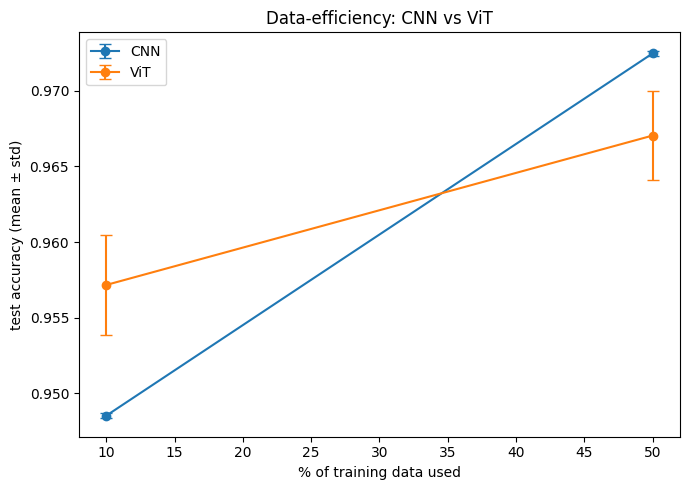

In [ ]:
cnn_de_df = pd.read_csv('/content/CNN csv/data_efficiency_CNN.csv')
vit_de_df = pd.read_csv('/content/ViT csv/data_efficiency_ViT.csv')

de_combined = pd.concat([cnn_de_df, vit_de_df], ignore_index=True)
de_combined_summary = de_combined.groupby(['model', 'fraction']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
).reset_index()
de_combined_summary.to_csv('MERGED_data_efficiency_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ['CNN', 'ViT']:
    sub = de_combined_summary[de_combined_summary['model'] == model_name].sort_values('fraction')
    ax.errorbar(sub['fraction'] * 100, sub['accuracy_mean'], yerr=sub['accuracy_std'], marker='o', capsize=4, label=model_name)
ax.set_xlabel('% of training data used')
ax.set_ylabel('test accuracy (mean ± std)')
ax.set_title('Data-efficiency: CNN vs ViT')
ax.legend()
plt.tight_layout()
plt.savefig('MERGED_data_efficiency_plot.png', dpi=150)
plt.show()

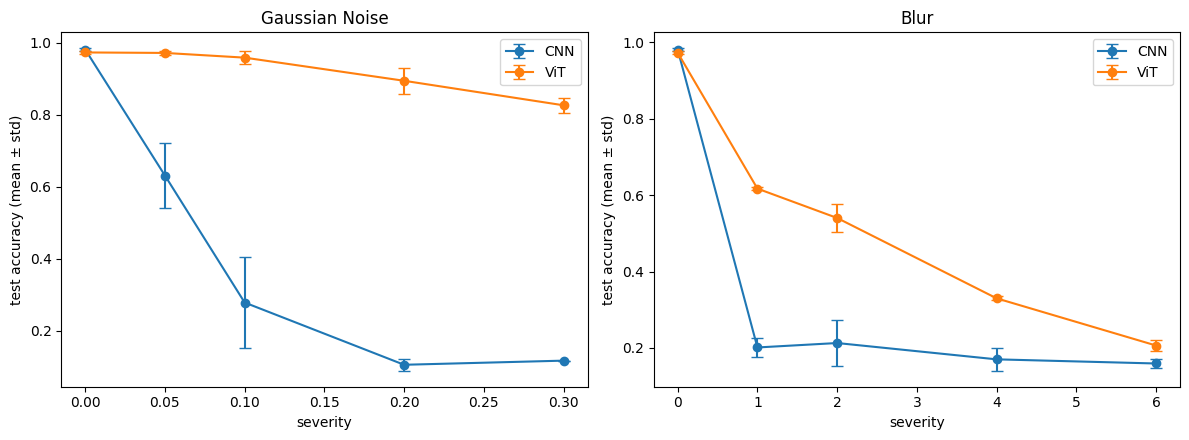

In [ ]:
cnn_rob_df = pd.read_csv('/content/CNN csv/robustness_CNN.csv')
vit_rob_df = pd.read_csv('/content/ViT csv/robustness_ViT.csv')

rob_combined = pd.concat([cnn_rob_df, vit_rob_df], ignore_index=True)
rob_combined_summary = rob_combined.groupby(['model', 'corruption', 'severity']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
).reset_index()
rob_combined_summary.to_csv('MERGED_robustness_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, corruption_name in zip(axes, ['gaussian_noise', 'blur']):
    sub_all = rob_combined_summary[rob_combined_summary['corruption'] == corruption_name]
    for model_name in ['CNN', 'ViT']:
        sub = sub_all[sub_all['model'] == model_name].sort_values('severity')
        ax.errorbar(sub['severity'], sub['accuracy_mean'], yerr=sub['accuracy_std'], marker='o', capsize=4, label=model_name)
    ax.set_xlabel('severity')
    ax.set_ylabel('test accuracy (mean ± std)')
    ax.set_title(corruption_name.replace('_', ' ').title())
    ax.legend()
plt.tight_layout()
plt.savefig('MERGED_robustness_plots.png', dpi=150)
plt.show()